Importing Google Colab Repository

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing Libraries

In [ ]:
import os # used for path handling , environment variables & running system commands
import numpy as np # used for mathematical operations , Linear Algebra , Statistical Calculations
import random # used for generating random values for augmentation
import tensorflow as tf # Used for train,build & run of Deep Learning Models
import seaborn as sns

from PIL import Image , ImageEnhance # used for opening & Enhancing images
from tensorflow.keras.utils import load_img, img_to_array # used for Loading Images
from tensorflow.keras.models import Sequential # used for creating & building a Sequential Model
from tensorflow.keras import layers # used for model layers
from tensorflow.keras.optimizers import Adam # used for optimizing the model
from tensorflow.keras.applications.vgg16 import VGG16 , preprocess_input # used for importing VGG16 pre trained_model
from sklearn.utils import shuffle # used for shuffling of data
from sklearn.metrics import confusion_matrix # used for creating confusion matrix
from tensorflow.keras.layers import InputLayer # Defines input shape of MRI Images
from tensorflow.keras.layers import Flatten # Used for Converting extracted feature maps into 1D Vector Classification
from tensorflow.keras.layers import Dense # Used for learning Tumor Pattern(Tumor/No Tumor)
from tensorflow.keras.layers import Dropout # used for reducing of Overfitting
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Used For Data Augmentation




Loading Dataset

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import tensorflow as tf
import numpy as np

# Directories for Training & Testing data
train_dir= '/content/drive/MyDrive/MRI Images (1)/Training/'
test_dir = '/content/drive/MyDrive/MRI Images (1)/Testing/'

print ("Train path exists:", os.path.isdir(train_dir))
print ("Test path exists:" , os.path.isdir(test_dir))

if os.path.isdir(train_dir):
    print("Train class folders:", sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]))
if os.path.isdir(test_dir):
    print("Test class folder:", sorted([d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))]))


SEED = 42
IMG_SIZE = (224,224)
BATCH_SIZE = 32
VAL_SPLIT = 0.20

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode = "categorical",
    validation_split = VAL_SPLIT,
    subset = "training",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    color_mode = "rgb"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode = "categorical",
    validation_split = VAL_SPLIT,
    subset = "validation",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    color_mode = "rgb",
    shuffle = False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode = "categorical",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    color_mode = "rgb",
    shuffle = False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Class names:", class_names)
print("Number classes:", num_classes)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed = SEED).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

def class_counts(ds, k):
  counts= np.zeros((k,), dtype=np.int64)
  for _, y in ds.unbatch():
      counts += y.numpy().astype(np.int64)
  return counts

counts = class_counts(train_ds, num_classes)
total = int(counts.sum())
class_weight = {i: float(total / (num_classes * max(int(counts[i]), 1))) for i in range (num_classes)}
print("Train counts:", dict(zip(class_names, counts.tolist())))
print("Class weights:", class_weight)










Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train path exists: True
Test path exists: True
Train class folders: ['glioma', 'meningioma', 'notumor', 'pituitary']
Test class folder: ['glioma', 'meningioma', 'notumor', 'pituitary']
Found 5712 files belonging to 4 classes.
Using 4570 files for training.
Found 5712 files belonging to 4 classes.
Using 1142 files for validation.
Found 1311 files belonging to 4 classes.
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number classes: 4
Train counts: {'glioma': 1077, 'meningioma': 1090, 'notumor': 1247, 'pituitary': 1156}
Class weights: {0: 1.0608170844939646, 1: 1.048165137614679, 2: 0.9161988773055333, 3: 0.9883217993079585}


Data Visualization

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
No of Classes: 4


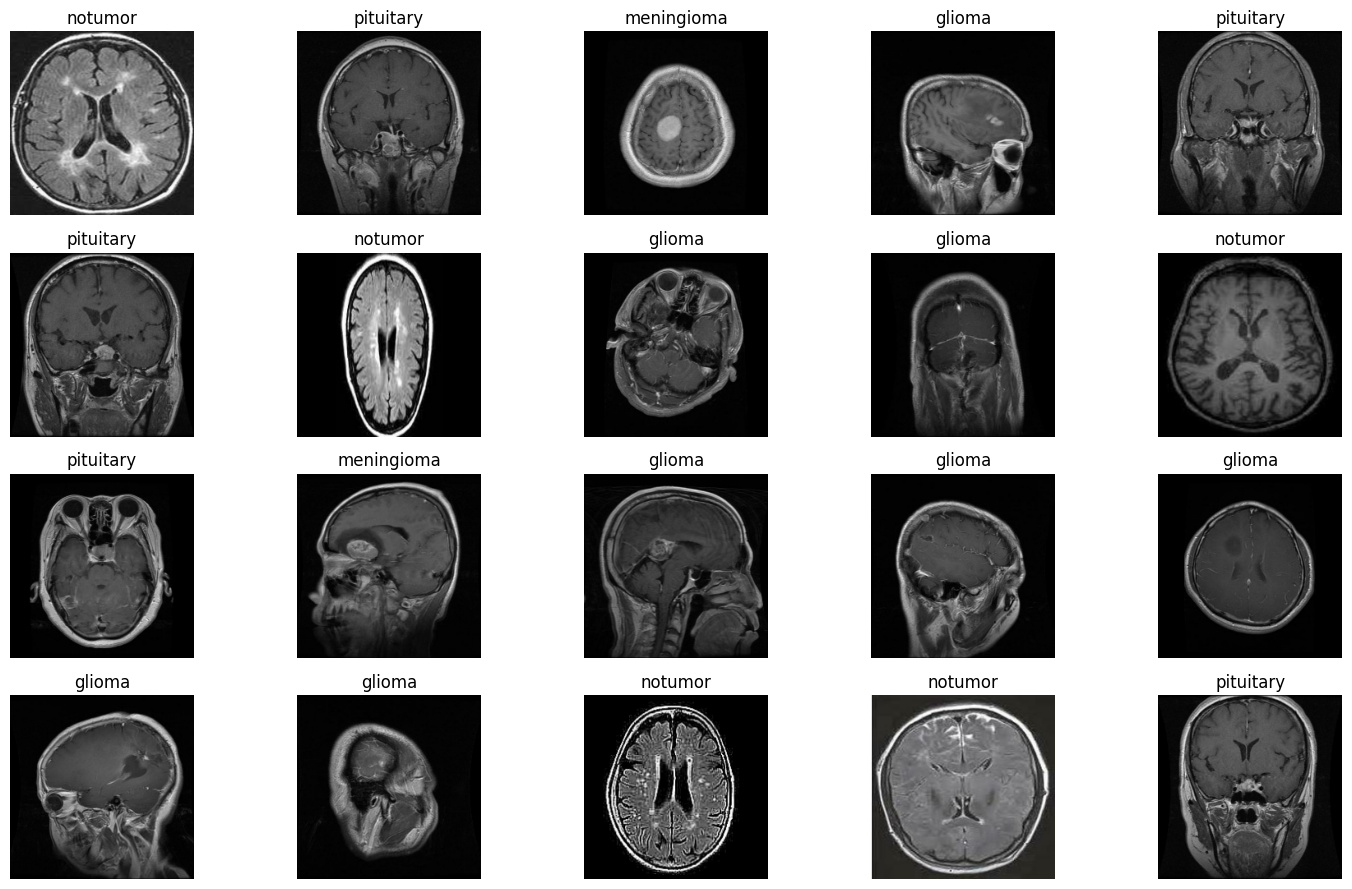

class counts: {'glioma': 1077, 'meningioma': 1090, 'notumor': 1247, 'pituitary': 1156}


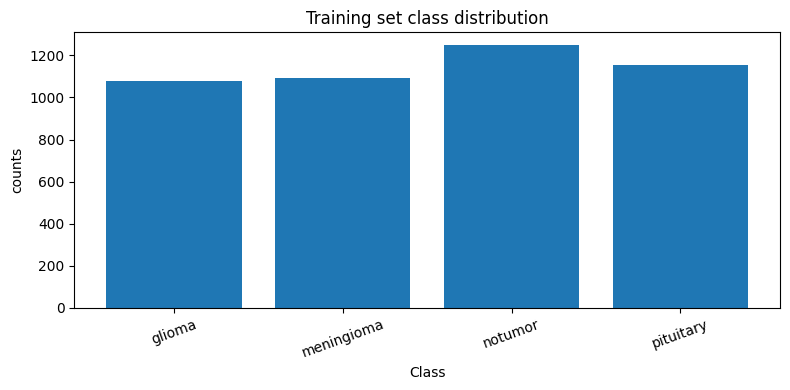

data_augmentation not found. Skipping augmented preview.


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


print("Classes:", class_names)
print("No of Classes:", len(class_names))

plt.figure(figsize=(15,9))
for images, labels in train_ds.take(1):
  for i in range(20):
    ax = plt.subplot(4,5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    label_idx = int(tf.argmax(labels[i]).numpy())
    plt.title(class_names[label_idx])
    plt.axis("off")
plt.tight_layout()
plt.show()

counts = np.zeros((len(class_names),), dtype=np.int64)
for _, y in train_ds.unbatch():
   class_idx = int(tf.argmax(y).numpy())
   counts[class_idx] += 1

print("class counts:", dict(zip(class_names, counts.tolist())))


plt.figure(figsize=(8,4))
plt.bar(class_names, counts)
plt.title("Training set class distribution")
plt.xlabel("Class")
plt.ylabel("counts")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


if "data_augmentation" in globals():
  plt.figure(figsize=(15,9))
  for images, labels in train_ds.take(1):
    aug = data_augmentation(images)
    for i in range(20):
      ax = plt.subplot(4,5, i+1)
      plt.imshow(aug[i].numpy().astype("uint8"))
      label_idx = int(tf.argmax(labels[i]).numpy())
      plt.title(class_names[label_idx])
      plt.axis("off")

  plt.tight_layout()
  plt.show()
else:
    print("data_augmentation not found. Skipping augmented preview.")








Image Processing

In [ ]:
# image Augmentation Function
def augment_image(image):
  image = Image.fromarray(np.unit8(image))
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
  image = np.array(image)/255.0
  return image


# load images and apply Augmentation

def open_images(paths):
  iamges = []
  for path in paths:
    image = load_img(path,target_size=(IMAGE_SIZE,IMAGE_SIZE))
    img = augment_image(img)
    image.append(img)
  return np.array(image)

 # Encode Labels
def encode_labels(labels):
  unique_labels = (os.listdir(train_dir))
  encoded = [unique_labels.index(label) for label in unique_labels]
  return encoded

# Data Generator for Batching
def datagen(paths,labels, batch_size = 12 , epochs=1):
  for _ in range(epochs):
    for i in range(0, len(paths), batch_size):
      batch_paths = paths[i:i+batch_size]
      batch_labels = labels[i:i+ batch_size]
      batch_images = open_images(batch_paths) # Used for & Augment Images
      batch_labels = encode_labels(batch_labels) # Used for encode labels
      yield batch_images, batch_labels  # Yield the batch






Model                                 
I am Using VGG16 for Transfer Learning

Transfer Learning with VGG16 is a widely adopted technique in medical image classification, particular for the MRI Based tumor detection. VGG16 is a Deep Convolutional Neural Network originally trained on large scale ImageNet dataset, enabling it to learn rich and generalized visual features such as edges, textures and shapes. In Transfer Learning the pre trained convolutional Layer of VGG16 are remained as a fixed feature extractor while the top layer are removed and replaced with new layers tailored to specific task. these newly added layers are then trained on target dataset such as different categories of brain tumors. while the core feature extractor remains unchanged. This approach significantly reduces training time minimize the need of large datasets and improves model performance by leveraging previously learned visula patterns. As a transfer VGG16 transfer learning offers a robust, efficient and highly accurate solution for mediacl images tasks

In [ ]:
train_dir = '/content/drive/MyDrive/MRI Images (1)/Testing/'
print(os.listdir(train_dir))

['notumor', 'meningioma', 'glioma', 'pituitary']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


By Building VGG16 Based Model

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras import Input


IMAGE_SIZE = 224
NUM_CLASSES = 10

base_model = keras.applications.VGG16(
    include_top =False,
    weights = "imagenet",
    input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3)

)

base_model.trainable = False

inputs =Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.45)(x)
x = layers.Dense(
    256,
    activation = "relu",
    kernel_regularizer = keras.regularizers.l2(1e-4)

) (x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

model.summary()

base_model.trainable = True
for layer in base_model.layers[:-4]:
  layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5),
    loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.03),
    metrics=["accuracy"]
)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Model Training History                                                 

train_ds exists: True
val_ds exists : True
Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.5516 - loss: 2.9143 
Epoch 1: val_accuracy improved from -inf to 0.98949, saving model to best_vgg16.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 2310s 16s/step - accuracy: 0.5522 - loss: 2.9064 - val_accuracy: 0.9895 - val_loss: 0.1788 - learning_rate: 0.0010
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7483 - loss: 0.7789 
Epoch 2: val_accuracy did not improve from 0.98949
143/143 ━━━━━━━━━━━━━━━━━━━━ 2214s 16s/step - accuracy: 0.7483 - loss: 0.7786 - val_accuracy: 0.9834 - val_loss: 0.3090 - learning_rate: 0.0010
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.7735 - loss: 0.6352 
Epoch 3: val_accuracy improved from 0.98949 to 0.99650, saving model to best_vgg16.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 2249s 16s/step - accuracy: 0.7735 - loss: 0.6351 - val_accuracy: 0.9965 - val_loss: 0.1870 - learning_rate: 0.0010
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━

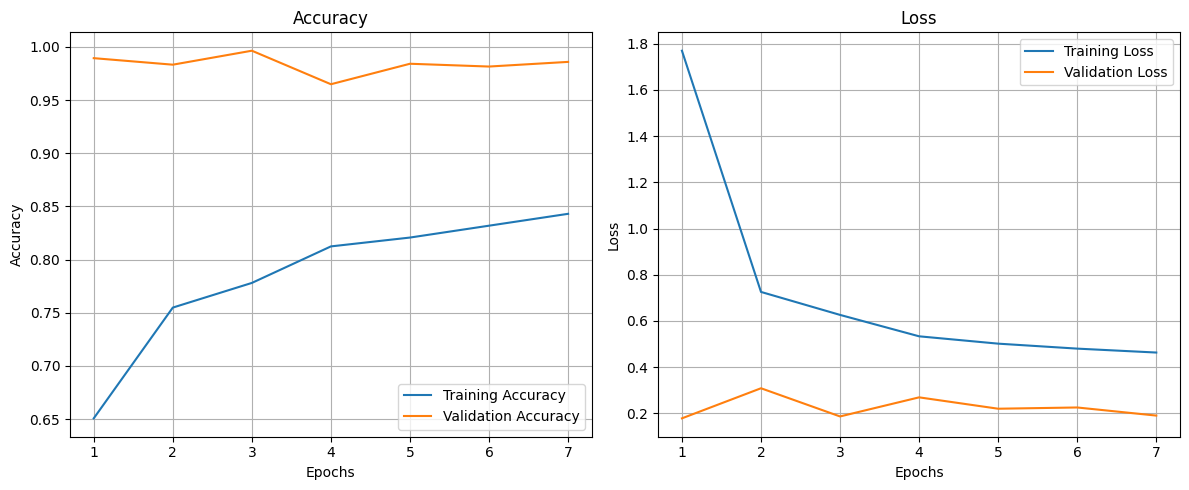

Best val accuracy: 0.996497392654419
Best epoch: 3


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,regularizers
import matplotlib.pyplot as plt

print("train_ds exists:", "train_ds" in globals())
print("val_ds exists :", "val_ds" in globals())

IMAGE_SIZE = 224
NUM_CLASSES = train_ds.element_spec[1].shape[-1]


base_model = keras.applications.VGG16(
    include_top = False,
    weights = "imagenet",
    input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.45)(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs,outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]

)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_vgg16.keras",
        monitor = "val_accuracy",
        save_best_only=True,
        mode = "max",
        verbose = 1
    ),
    keras.callbacks.EarlyStopping(
        monitor = "val_loss",
        patience = 6,
        restore_best_weights = True,
        verbose = 1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor = "val_loss",
        factor = 0.2,
        patience = 3,
        min_lr = 1e-6,
        verbose = 1
    )
]

EPOCHS = 10
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = EPOCHS,
    callbacks = callbacks
)

epochs_range = range(1, len(history.history["accuracy"]) +1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, history.history["accuracy"], label="Training Accuracy")
plt.plot(epochs_range, history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs_range, history.history["loss"], label="Training Loss")
plt.plot(epochs_range, history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

best_val_acc = max(history.history["val_accuracy"])
best_epoch = history.history["val_accuracy"].index(best_val_acc) +1
print("Best val accuracy:", float(best_val_acc))
print("Best epoch:", best_epoch)



Model Classification Report

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from sklearn.metrics import classification_report
import numpy as np
import os

# By Pereparing Test paths & Labels
IMAGE_SIZE = 224
BATCH_SIZE = 32
SEED = 42

test_dir = '/content/drive/MyDrive/MRI Images (1)/Testing/'
train_dir = '/content/drive/MyDrive/MRI Images (1)/Training/'


train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    validation_split = 0.20,
    rotation_range = 12,
    width_shift_range = 0.08,
    height_shift_range = 0.08,
    zoom_range = 0.12,
    horizontal_flip = True
)

val_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    validation_split = 0.20
)

test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size= BATCH_SIZE,
    class_mode='sparse',
    subset = "training",
    shuffle = True,
    seed = SEED
)
val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE,
    class_mode = 'sparse',
    subset = "validation",
    shuffle = False

)


test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size= BATCH_SIZE,
    class_mode= 'sparse',
    shuffle=False

)

# Building Model
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE,3), include_top=False, weights='imagenet')

base_model.trainable = False

model = keras.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.45),
    Dense(256, activation="relu", kernel_regularizer = keras.regularizers.l2(1e-4)),
    Dropout(0,30),
    Dense(train_generator.num_classes, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Training The Model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data= val_generator
)

# Classification Report
y_true = test_generator.classes
probs = model.predict(test_generator, verbose=0)
y_pred = np.argmax(probs, axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names= class_names, digits=4))




Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 3079s 22s/step - accuracy: 0.3805 - loss: 2.7632 - val_accuracy: 0.6372 - val_loss: 1.4437
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 3033s 21s/step - accuracy: 0.6490 - loss: 1.1327 - val_accuracy: 0.6994 - val_loss: 1.2478
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 3082s 21s/step - accuracy: 0.7230 - loss: 0.8464 - val_accuracy: 0.7169 - val_loss: 1.2431
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 3064s 21s/step - accuracy: 0.7694 - loss: 0.7290 - val_accuracy: 0.7283 - val_loss: 1.1344
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 3022s 21s/step - accuracy: 0.7901 - loss: 0.6582 - val_accuracy: 0.7379 - val_loss: 1.0239
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 3020s 21s/step - accuracy: 0.7926 - loss: 0.6405 - val_accuracy: 0.7257 - val_loss: 1.1319
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 3059s 21s/step - accuracy: 0.8106 - loss: 0.5900 - val_accuracy: 0.7257 - val_loss: 1.0794
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 3041s 21s/step - accuracy: 0.8165 - loss: 0

Building A Confusion Matrix

41/41 ━━━━━━━━━━━━━━━━━━━━ 235s 6s/step
Confusion Matrix:
[[259  41   0   0]
 [  3 295   8   0]
 [  0   1 404   0]
 [  2  24   1 273]]


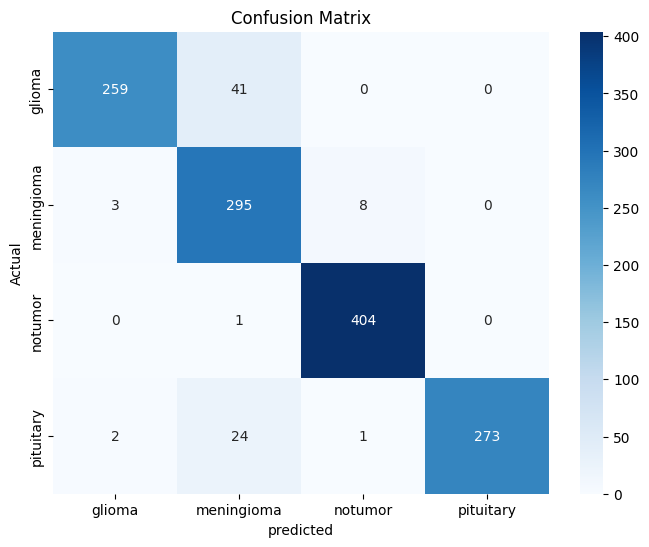

In [ ]:
import os
import tensorflow as tf
import seaborn as sns

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
from sklearn.preprocessing import LabelEncoder


test_dir = '/content/drive/MyDrive/MRI Images (1)/Testing/'

test_paths = []
test_labels = []

for label in os.listdir(test_dir):
  label_dir = os.path.join(test_dir, label)
  if os.path.isdir(label_dir):
    for img_file in os.listdir(label_dir):

      test_paths.append(os.path.join(label_dir, img_file))
      test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)


# By Loading & Preprocessing Images
def open_images(paths, target_size=(128,128)):
  images = []
  for path in paths:
    img = load_img(path, target_size=target_size)
    img = img_to_array(img)
    img = tf.keras.applications.vgg16.preprocess_input(img)
    images.append(img)
  return np.array(images)

test_images = open_images(test_paths)


# By Encode Labels
le = LabelEncoder()
test_Labels_encoded = le.fit_transform(test_labels)
class_names = le.classes_

# By Making True Labels and Predictions
test_predictions = model.predict(test_images)
y_pred = np.argmax(test_predictions, axis=1)

# Building Confusion Matrix
conf_matrix = confusion_matrix(test_Labels_encoded,y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# By Creating plot Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels= class_names,
            yticklabels= class_names)

plt.xlabel('predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



Frequency Distribution Classes

Frequency Distribution Table:
Disease
notumor       1595
pituitary     1457
meningioma    1339
glioma        1321
Name: count, dtype: int64


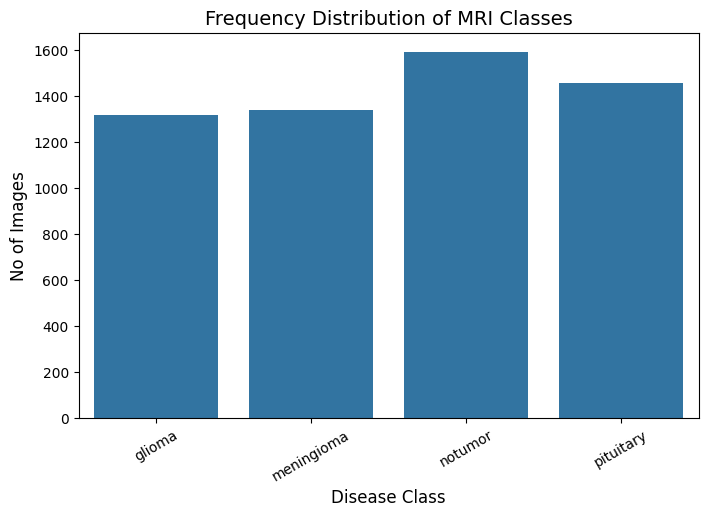

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_dir = '/content/drive/MyDrive/MRI Images (1)/Training'

labels = []

for class_name in os.listdir(data_dir):
  class_path = os.path.join(data_dir, class_name)
  if os.path.isdir(class_path):
    for img in os.listdir(class_path):
      labels.append(class_name)


tabular_data = pd.DataFrame({'Disease': labels})

frequency_table = tabular_data['Disease'].value_counts()
print("Frequency Distribution Table:")
print(frequency_table)


plt.figure(figsize=(8,5))
sns.countplot(x='Disease', data=tabular_data)
plt.xlabel ('Disease Class', fontsize=12)
plt.ylabel ('No of Images', fontsize=12)
plt.title('Frequency Distribution of MRI Classes', fontsize=14)
plt.xticks(rotation=30)
plt.show()


Gender Of Patient

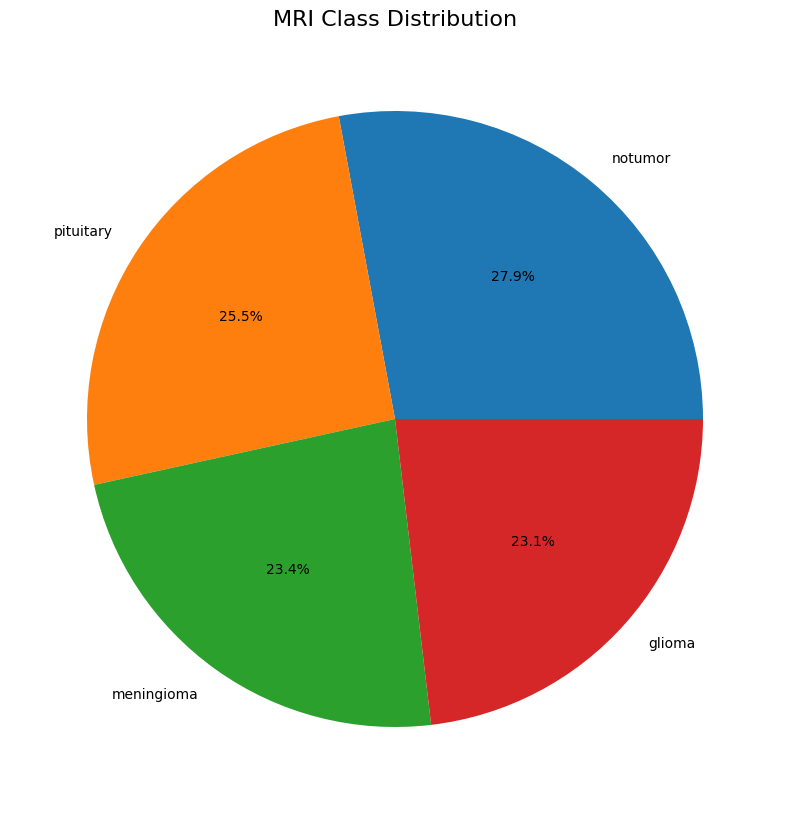

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

data_dir = '/content/drive/MyDrive/MRI Images (1)/Training'

labels = []
for class_name in os.listdir(data_dir):
  class_path = os.path.join(data_dir, class_name)
  if os.path.isdir(class_path):
    for img_file in os.listdir(class_path):
      labels.append(class_name)

tabular_data = pd.DataFrame({'Disease': labels})

plt.figure(figsize=(10,10))
plt.pie(tabular_data['Disease'].value_counts(), labels=tabular_data['Disease'].value_counts().index, autopct="%.1f%%")
startangle = 90
colors=['#ff9999','#66b3ff','#99ff99','#ffcc99']
plt.title('MRI Class Distribution', fontsize=16)
plt.show()

Histogram Of Patients

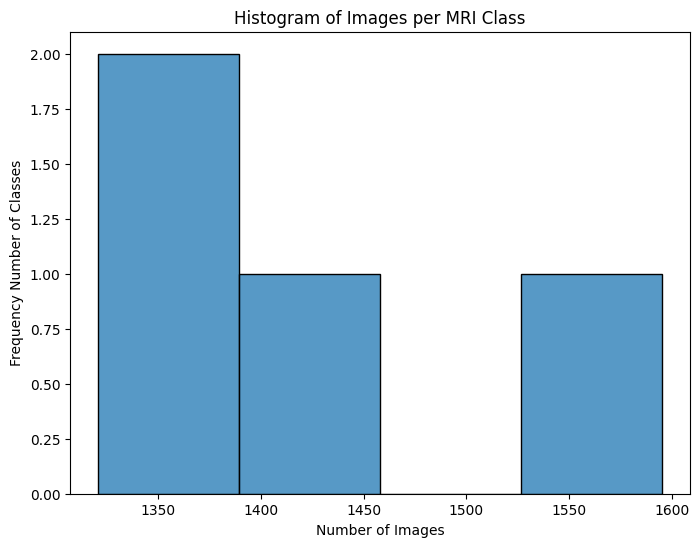

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = '/content/drive/MyDrive/MRI Images (1)/Training'

labels = []
for class_name in os.listdir(data_dir):
  class_path = os.path.join(data_dir, class_name)
  if os.path.isdir(class_path):
    for img_file in os.listdir(class_path):
      labels.append(class_name)


tabular_data = pd.DataFrame({'Disease': labels})

class_counts = tabular_data['Disease'].value_counts()

plt.figure(figsize=(8,6))
sns.histplot(class_counts,bins=len(class_counts), kde=False)
plt.xlabel('Number of Images')
plt.ylabel('Frequency Number of Classes')
plt.title('Histogram of Images per MRI Class')
plt.show()









Roc Curve Plot

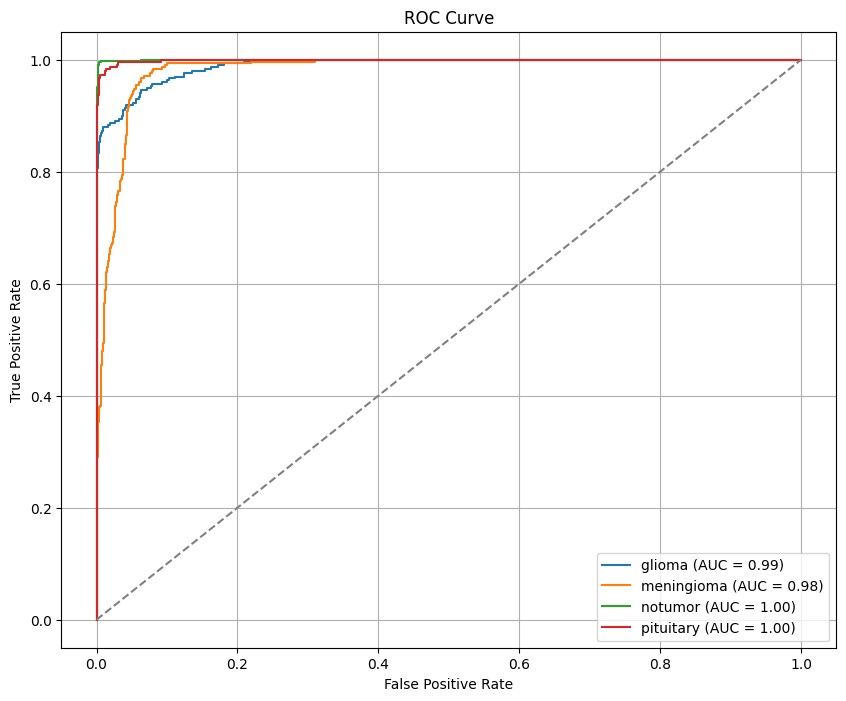

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc

le = LabelEncoder()
test_labels_encoded = le.fit_transform(test_labels)
class_names = le.classes_

# Binarize Label for multiclass ROC
num_classes = len(class_names)
test_labels_bin = label_binarize(
    test_labels_encoded,
    classes= np.arange(num_classes)
 )
test_predictions_bin = test_predictions

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10,8))

for i in range(num_classes):
  fpr[i], tpr[i], _ = roc_curve(
      test_labels_bin[:, i],
      test_predictions_bin[:, i]
  )
  roc_auc[i] = auc(fpr[i], tpr[i])

  plt.plot(
      fpr[i],
      tpr[i],
      label = f'{class_names[i]} (AUC = {roc_auc[i]:.2f})'
  )


plt.plot([0,1],[0,1] , linestyle='--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()




3D MRI Visualization

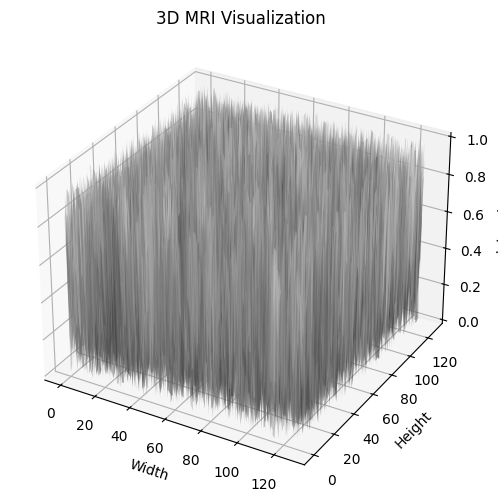

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

volume = np.random.rand(60,128,128)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

X, Y =  np.meshgrid(
    np.arange(volume.shape[2]),
    np.arange(volume.shape[1])
)
for i in range(0, volume.shape[0], 5):
  ax.plot_surface(X, Y, volume[i], cmap='gray', alpha= 0.3)

ax.set_title("3D MRI Visualization")
ax.set_xlabel("Width")
ax.set_ylabel("Height")
ax.set_zlabel("Intensity")
plt.show()

Save the Model

In [ ]:
from google.colab import drive
from tensorflow.keras.models import load_model
import os

drive.mount('/content/drive')

model_path = '/content/drive/MyDrive/brain_tumor_model.keras'
model_save = '/content/drive/MyDrive/brain_tumor_model.h5'

if os.path.exists(model_path):
  model = load_model(model_path)
  print("Model Loaded Successfully")


  model.save(save_path)
  print(f"Model saved successfulyy at: {save_path}")

else:
  print(f"Model file not found at {model_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model file not found at /content/drive/MyDrive/brain_tumor_model.keras
